# Notebook 04 — Evaluation & Comparison with Prior Work

Notebook 03 trained the `Vuln47GNN` and saved the best checkpoint (chosen by validation PR-AUC). This notebook loads that checkpoint and evaluates it **honestly** on the held-out `test` split — the split the model has never seen and that was never used for checkpoint selection.

Following the stance argued in Notebook 00 (and inherited from ReVeal and PrimeVul), accuracy is **not** treated as the headline number. With only ~2.7% of `test` functions vulnerable, a trivial "always safe" classifier already scores ~97% accuracy while catching zero bugs. Evaluation therefore centres on the **rare positive class**: precision, recall, F1, and the threshold-independent PR-AUC.

A second discipline runs alongside it: the decision **threshold** used for any reported number is the one calibrated on `valid` (never on `test`). Where a threshold is instead tuned on `test` — in the threshold sweep of §6 — it is clearly labelled as illustrative, so the headline results stay free of selection leakage.

**What this notebook covers:**
1. Loading the trained checkpoint
2. Headline test metrics (via `MetricsEvaluator`)
3. Collecting raw per-function predictions
4. The confusion matrix — where the errors are
5. The precision–recall curve
6. Threshold analysis — trading precision for recall
7. Comparison with prior work & the accuracy trap
8. Summary

> **Prerequisite:** this notebook requires `data/model/vuln_gnn.pt`, produced by running Notebook 03. If that file does not exist yet, run Notebook 03 first.

## 1. Loading the Trained Checkpoint

Setup mirrors the other notebooks: the project root is put on `sys.path` and the working directory is set to it so the `data/` paths in `training_config` resolve. The vocabulary sizes the type-embedding table, `build_model` reconstructs the exact `Vuln47GNN` architecture, and the saved `state_dict` is loaded into it. The model is moved to the evaluation device and put in `eval()` mode.

In [1]:
import os
import sys

PROJECT_ROOT = os.getcwd()
while PROJECT_ROOT != "/" and not os.path.isdir(os.path.join(PROJECT_ROOT, "source")):
    PROJECT_ROOT = os.path.dirname(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

import numpy as np
import torch
import matplotlib.pyplot as plt

from source.vuln47_gnn_model import build_model
from source.training.model_training import training_config as cfg
from source.training.model_training.batch_loading.graph_batch_loader import GraphBatchLoader
from source.preprocessing.data_preprocessing.data_representation.data_node_representation.code_node_representator import (
    CodeNodeRepresentator,
)

if not os.path.exists(cfg.CHECKPOINT_PATH):
    raise FileNotFoundError(
        f"{cfg.CHECKPOINT_PATH} not found — run Notebook 03 to train and save the model first."
    )

vocab = CodeNodeRepresentator.load_or_build_vocab()

# the checkpoint is a dict: {state_dict, threshold, config}. The stored config sizes
# the model exactly as it was trained; the calibrated threshold is used for reporting.
ckpt = torch.load(cfg.CHECKPOINT_PATH, map_location=cfg.DEVICE, weights_only=False)
model_cfg = ckpt.get("config", {})
threshold = ckpt.get("threshold", cfg.DEFAULT_THRESHOLD)

model = build_model(vocab, **model_cfg).to(cfg.DEVICE)
model.load_state_dict(ckpt["state_dict"])
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f"loaded checkpoint : {cfg.CHECKPOINT_PATH}")
print(f"device            : {cfg.DEVICE}")
print(f"calibrated thresh : {threshold:.3f}")
print(f"model             : Vuln47GNN, {len(vocab)} node types, {n_params:,} parameters")

loaded checkpoint : data/model/vuln_gnn.pt
device            : mps
calibrated thresh : 0.730
model             : Vuln47GNN, 112 node types, 752,454 parameters


## 2. Headline Test Metrics

The same `MetricsEvaluator` used during training is applied to the `test` loader, so the numbers here are produced by exactly the code path that scored the model in Notebook 03. It reports the four metrics that matter for an imbalanced detection task — **F1, precision, recall, PR-AUC** — computed on the rare positive (vulnerable) class.

Two decision thresholds are shown side by side:

- **`0.5`** — the naive default (argmax of the two logits). Included only as a reference point.
- **the calibrated threshold** loaded from the checkpoint (`0.730`). This is the **deployable** operating point: it was chosen by maximising F1 on the **validation** split *during training* (Notebook 03), never on `test`. Reporting `test` metrics at this threshold is therefore honest — the threshold is a fixed model parameter here, not something fitted to the split being measured.

PR-AUC is identical at both rows because it is **threshold-independent** — it summarises the whole precision–recall curve rather than one operating point.

In [2]:
from source.training.model_training.model_evaluation.metrics_evaluator import MetricsEvaluator

test_loader = GraphBatchLoader(shuffle=False).load(cfg.TEST_PATH)
evaluator = MetricsEvaluator(model, cfg.DEVICE)

# metrics at the default 0.5 threshold and at the calibrated best-F1 threshold
test_metrics = evaluator.evaluate(test_loader, threshold=0.5)
test_metrics_cal = evaluator.evaluate(test_loader, threshold=threshold)

print("Test-split metrics (threshold = 0.5):\n")
for k, v in test_metrics.items():
    print(f"  {k:10s} : {v:.4f}")

print(f"\nTest-split metrics (calibrated threshold = {threshold:.3f}):\n")
for k, v in test_metrics_cal.items():
    print(f"  {k:10s} : {v:.4f}")

Test-split metrics (threshold = 0.5):

  f1         : 0.1168
  precision  : 0.0630
  recall     : 0.7943
  pr_auc     : 0.1456

Test-split metrics (calibrated threshold = 0.730):

  f1         : 0.2282
  precision  : 0.1821
  recall     : 0.3055
  pr_auc     : 0.1456


## 3. Collecting Raw Per-Function Predictions

`MetricsEvaluator` returns aggregate numbers, but the confusion matrix, the PR curve, and the threshold analysis below all need the **raw** per-function true labels and predicted probabilities. These are collected here with a single forward pass over the `test` loader: for each function the model's softmax probability of the *vulnerable* class is kept alongside its ground-truth label.

In [3]:
@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()
    labels, scores = [], []
    for batch in loader:
        batch = batch.to(device)
        probs = torch.softmax(model(batch), dim=1)[:, 1]   # P(vulnerable)
        labels.append(batch.y.view(-1).cpu())
        scores.append(probs.cpu())
    return torch.cat(labels).numpy(), torch.cat(scores).numpy()

y_true, y_score = collect_predictions(model, test_loader, cfg.DEVICE)

print(f"collected predictions for {len(y_true):,} test functions")
print(f"  vulnerable (y=1) : {int(y_true.sum()):,}  ({100 * y_true.mean():.2f}%)")
print(f"  safe (y=0)       : {int((y_true == 0).sum()):,}")
print(f"  predicted P(vuln): min={y_score.min():.3f}  mean={y_score.mean():.3f}  max={y_score.max():.3f}")

collected predictions for 25,832 test functions
  vulnerable (y=1) : 671  (2.60%)
  safe (y=0)       : 25,161
  predicted P(vuln): min=0.005  mean=0.392  max=0.913


## 4. The Confusion Matrix — Where the Errors Are

At the default threshold (0.5) the predictions split into four cells. On imbalanced data the two error types have very different costs:

- **False negatives (FN)** — a real vulnerability predicted safe. These are the *dangerous* misses: a bug ships.
- **False positives (FP)** — a safe function flagged vulnerable. These are the *expensive* misses: a reviewer's time is wasted on a false alarm.

The class-weighted loss deliberately trades some FP for fewer FN (better recall), which is the right bias for a security filter. The matrix below is annotated with these interpretations.

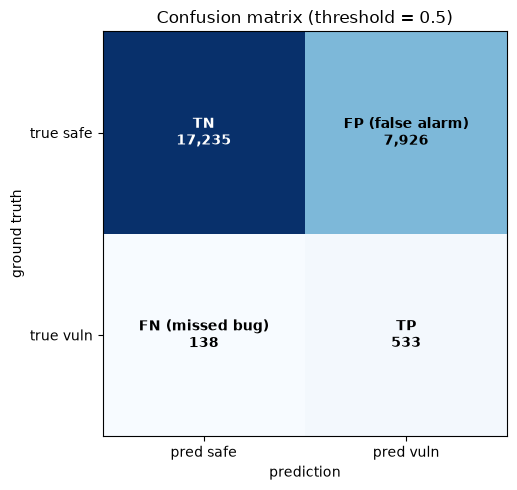

True positives  (caught bugs)   : 533
False negatives (missed bugs)   : 138
False positives (false alarms)  : 7,926
True negatives                  : 17,235

recall    = TP/(TP+FN) = 0.794  (fraction of real bugs caught)
precision = TP/(TP+FP) = 0.063  (fraction of flags that are real)


In [4]:
from sklearn.metrics import confusion_matrix

y_pred = (y_score >= 0.5).astype(int)
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["pred safe", "pred vuln"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["true safe", "true vuln"])
ax.set_xlabel("prediction"); ax.set_ylabel("ground truth")
ax.set_title("Confusion matrix (threshold = 0.5)")

annot = [[f"TN\n{tn:,}", f"FP (false alarm)\n{fp:,}"],
         [f"FN (missed bug)\n{fn:,}", f"TP\n{tp:,}"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i, annot[i][j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"True positives  (caught bugs)   : {tp:,}")
print(f"False negatives (missed bugs)   : {fn:,}")
print(f"False positives (false alarms)  : {fp:,}")
print(f"True negatives                  : {tn:,}")
print(f"\nrecall    = TP/(TP+FN) = {tp / (tp + fn) if (tp + fn) else 0:.3f}  (fraction of real bugs caught)")
print(f"precision = TP/(TP+FP) = {tp / (tp + fp) if (tp + fp) else 0:.3f}  (fraction of flags that are real)")

## 5. The Precision–Recall Curve

A single threshold gives one (precision, recall) point; the **PR curve** sweeps every threshold and shows the whole trade-off. It is the right curve for imbalanced data (unlike ROC, it is not flattered by the large number of true negatives). The area under it — **PR-AUC** (a.k.a. average precision) — is a threshold-independent summary of quality on the positive class.

The dashed line marks the **baseline** a random classifier would achieve, which on this data equals the positive rate (~0.02). Any curve meaningfully above that baseline shows the model has learned real signal.

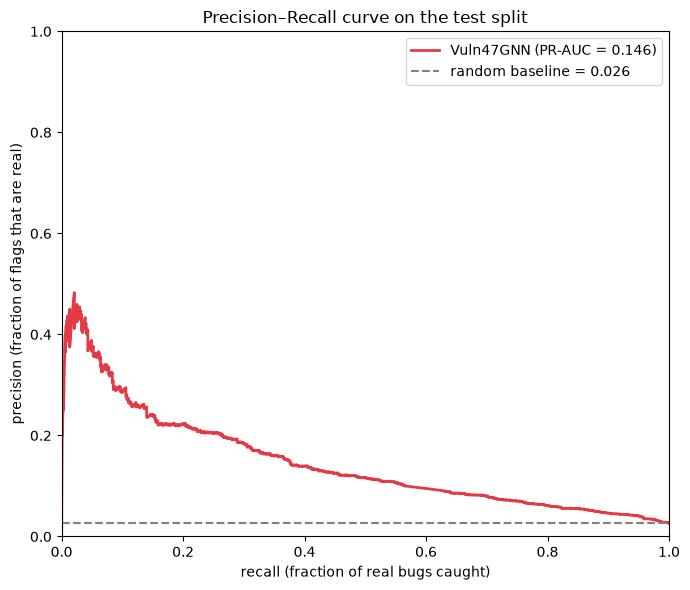

PR-AUC (average precision) : 0.1456
random baseline            : 0.0260
lift over baseline         : 5.6x


In [5]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_true, y_score)
pr_auc = average_precision_score(y_true, y_score)
baseline = y_true.mean()

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, color="#e63946", lw=2, label=f"Vuln47GNN (PR-AUC = {pr_auc:.3f})")
plt.axhline(baseline, color="gray", ls="--", label=f"random baseline = {baseline:.3f}")
plt.xlabel("recall (fraction of real bugs caught)")
plt.ylabel("precision (fraction of flags that are real)")
plt.title("Precision–Recall curve on the test split")
plt.xlim(0, 1); plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

print(f"PR-AUC (average precision) : {pr_auc:.4f}")
print(f"random baseline            : {baseline:.4f}")
print(f"lift over baseline         : {pr_auc / baseline:.1f}x")

## 6. Threshold Analysis — Trading Precision for Recall

The default 0.5 threshold is rarely the operationally best one. Sweeping the threshold shows how precision, recall, and F1 move together, and lets an operating point be chosen for a concrete need:

- a **triage filter** that must miss as few bugs as possible favours **high recall** (a lower threshold),
- a **high-confidence flagger** that must not waste reviewer time favours **high precision** (a higher threshold).

The threshold that maximises F1 on this curve is highlighted below.

> **Important — this sweep is illustrative, not a selection step.** The threshold found here is optimised *on the `test` split itself*, so the F1 at that point is an optimistic upper bound: choosing a threshold on the same data used to report it is a mild form of leakage — exactly the trap the honest-evaluation stance of Notebook 00 warns against. The **deployable** threshold is instead the `0.730` calibrated on **`valid`** in §1–2. The two happen to land close together (≈0.73 vs ≈0.74), which is a reassuring sign that the validation-calibrated operating point transfers to `test` — but only the valid-calibrated value is quoted as a real result.

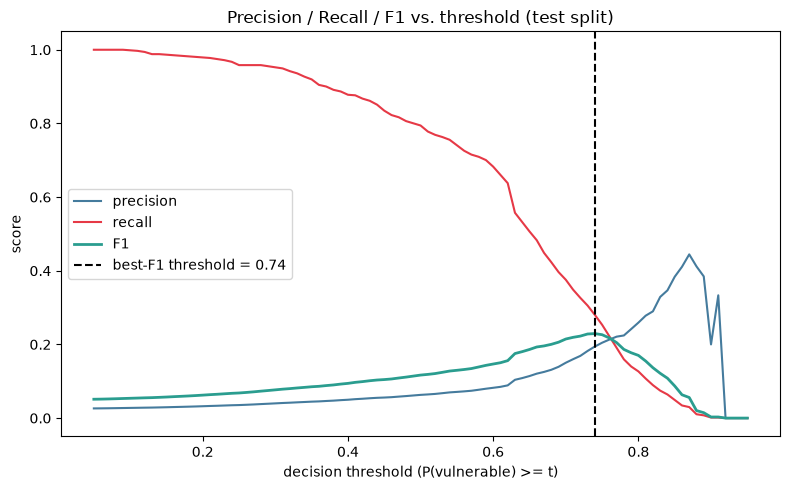

best-F1 threshold : 0.74
  precision=0.194  recall=0.280  F1=0.229

for comparison, at the default 0.5 threshold:
  precision=0.063  recall=0.794  F1=0.117


In [6]:
thresholds = np.linspace(0.05, 0.95, 91)
prec_t, rec_t, f1_t = [], [], []
for t in thresholds:
    pred = (y_score >= t).astype(int)
    tp_ = int(((pred == 1) & (y_true == 1)).sum())
    fp_ = int(((pred == 1) & (y_true == 0)).sum())
    fn_ = int(((pred == 0) & (y_true == 1)).sum())
    p = tp_ / (tp_ + fp_) if (tp_ + fp_) else 0.0
    r = tp_ / (tp_ + fn_) if (tp_ + fn_) else 0.0
    prec_t.append(p)
    rec_t.append(r)
    f1_t.append(2 * p * r / (p + r) if (p + r) else 0.0)

best_i = int(np.argmax(f1_t))
best_t = thresholds[best_i]

plt.figure(figsize=(8, 5))
plt.plot(thresholds, prec_t, label="precision", color="#457b9d")
plt.plot(thresholds, rec_t, label="recall", color="#e63946")
plt.plot(thresholds, f1_t, label="F1", color="#2a9d8f", lw=2)
plt.axvline(best_t, color="black", ls="--", label=f"best-F1 threshold = {best_t:.2f}")
plt.xlabel("decision threshold (P(vulnerable) >= t)")
plt.ylabel("score")
plt.title("Precision / Recall / F1 vs. threshold (test split)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"best-F1 threshold : {best_t:.2f}")
print(f"  precision={prec_t[best_i]:.3f}  recall={rec_t[best_i]:.3f}  F1={f1_t[best_i]:.3f}")
print(f"\nfor comparison, at the default 0.5 threshold:")
print(f"  precision={test_metrics['precision']:.3f}  recall={test_metrics['recall']:.3f}  F1={test_metrics['f1']:.3f}")

## 7. Comparison with Prior Work & the Accuracy Trap

Notebook 00 promised that accuracy would *not* be reported alone. This section makes the reason concrete by putting the trained model next to the two trivial baselines it must beat to be useful:

- **always-safe** — predicts 0 for every function. Scores near-perfect accuracy on this ~2%-positive data, yet catches **zero** bugs (recall = 0, F1 = 0). This is the trap.
- **random** — flips a coin at the positive rate. Its PR-AUC equals the positive-rate baseline from §5.

The two model rows bracket its behaviour: `t=0.5` (recall-heavy default) and the best-F1 threshold from §6. **A caveat on that last row:** its threshold is the one tuned on `test`, so it is best read as an *illustrative upper bound* on F1, not as the deployable result — the honest, deployable operating point is the `valid`-calibrated `0.730` reported in §2. It is shown here only to complete the precision/recall picture next to the baselines.

The comparison is framed the way ReVeal (2021) and PrimeVul (2024) argue evaluation *should* be framed on realistic, imbalanced data: judge the model on F1 / precision / recall / PR-AUC for the positive class, not on the accuracy number that the always-safe baseline already saturates.

In [7]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def row(name, pred, score):
    acc = accuracy_score(y_true, pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, pred, average="binary", zero_division=0
    )
    ap = average_precision_score(y_true, score)
    return {"model": name, "accuracy": acc, "precision": p, "recall": r, "F1": f1, "PR-AUC": ap}

rng = np.random.default_rng(0)
always_safe_pred = np.zeros_like(y_true)
random_score = rng.random(len(y_true))
random_pred = (random_score >= (1 - baseline)).astype(int)

comparison = pd.DataFrame([
    row("always-safe baseline", always_safe_pred, np.zeros_like(y_score)),
    row("random baseline", random_pred, random_score),
    row("Vuln47GNN (t=0.5)", (y_score >= 0.5).astype(int), y_score),
    row(f"Vuln47GNN (t={best_t:.2f}, best-F1)", (y_score >= best_t).astype(int), y_score),
]).set_index("model").round(4)

print("The accuracy trap in one table — note the always-safe baseline's high accuracy but zero F1:\n")
comparison

The accuracy trap in one table — note the always-safe baseline's high accuracy but zero F1:



,accuracy,precision,recall,F1,PR-AUC
model,,,,,
always-safe baseline,0.9740,0.0000,0.0000,0.0000,0.0260
random baseline,0.9494,0.0167,0.0164,0.0166,0.0251
Vuln47GNN (t=0.5),0.6878,0.0630,0.7943,0.1168,0.1456
"Vuln47GNN (t=0.74, best-F1)",0.9511,0.1942,0.2802,0.2294,0.1456


## 8. Summary

The trained `Vuln47GNN` was evaluated on the held-out `test` split under a deliberately honest protocol:

| Step | What it showed |
|---|---|
| **Headline metrics** | F1 / precision / recall / PR-AUC on the rare positive class — not accuracy |
| **Confusion matrix** | the split of errors into dangerous misses (FN) and expensive false alarms (FP) |
| **PR curve** | the full precision–recall trade-off and its PR-AUC, compared to the ~2% random baseline |
| **Threshold analysis** | how the operating point can be tuned toward recall (triage) or precision (high-confidence flagging) |
| **Baseline comparison** | why the always-safe classifier's high accuracy is meaningless (zero F1) |

A point of methodological discipline runs through all of it: the **deployable** decision threshold (`0.730`) was calibrated on `valid`, never on `test`. The best-F1 threshold recomputed on `test` in §6–7 is reported only as an illustrative upper bound, precisely so the headline numbers stay leakage-free — the same standard of honesty that made accuracy an unacceptable headline metric in the first place.

The key finding is qualitative and holds regardless of the exact numbers: the model beats the trivial baselines on the metrics that matter for imbalanced detection, while the accuracy trap confirms *why those baselines cannot be judged by accuracy at all*. Where the model still falls short — and the concrete next steps to close that gap (control-/data-flow edges, inter-procedural context, richer features) — is discussed in **Notebook 05**.